źródło danych: https://www.kaggle.com/datasets/emonsharkar/python-learning-and-exam-performance-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.dummy import DummyClassifier

In [2]:
df = pd.read_csv('python_learning_exam_performance.csv')
df.head()

,student_id,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,44,Nigeria,NaN,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,36,UK,NaN,3,3.5,62,1,47,1,0,3,7,24.8,0


In [3]:
df.shape[0]

3000

In [4]:
df.shape[1]

15

In [5]:
pd.isnull(df).sum()
# w moim datensatz nie ma żadnych braków jedyne co jest to 1062 None

,0
student_id,0
age,0
country,0
prior_programming_experience,1062
weeks_in_course,0
hours_spent_learning_per_week,0
practice_problems_solved,0
projects_completed,0
tutorial_videos_watched,0
uses_kaggle,0


In [6]:
#czyszczenie danych
#wykonuje replace specyficznie dla none i nan bo wiem ze nie ma pustych rubryk
df.replace('None', 'no_experience', inplace=True)
df.replace(np.nan, 'no_experience', inplace=True)
pd.isnull(df).sum()

,0
student_id,0
age,0
country,0
prior_programming_experience,0
weeks_in_course,0
hours_spent_learning_per_week,0
practice_problems_solved,0
projects_completed,0
tutorial_videos_watched,0
uses_kaggle,0


In [7]:
print(df.isnull().sum().sum())

0


analizowane kolumny: ['age', 'weeks_in_course', 'hours_spent_learning_per_week', 'practice_problems_solved', 'projects_completed', 'tutorial_videos_watched', 'debugging_sessions_per_week', 'self_reported_confidence_python', 'final_exam_score']


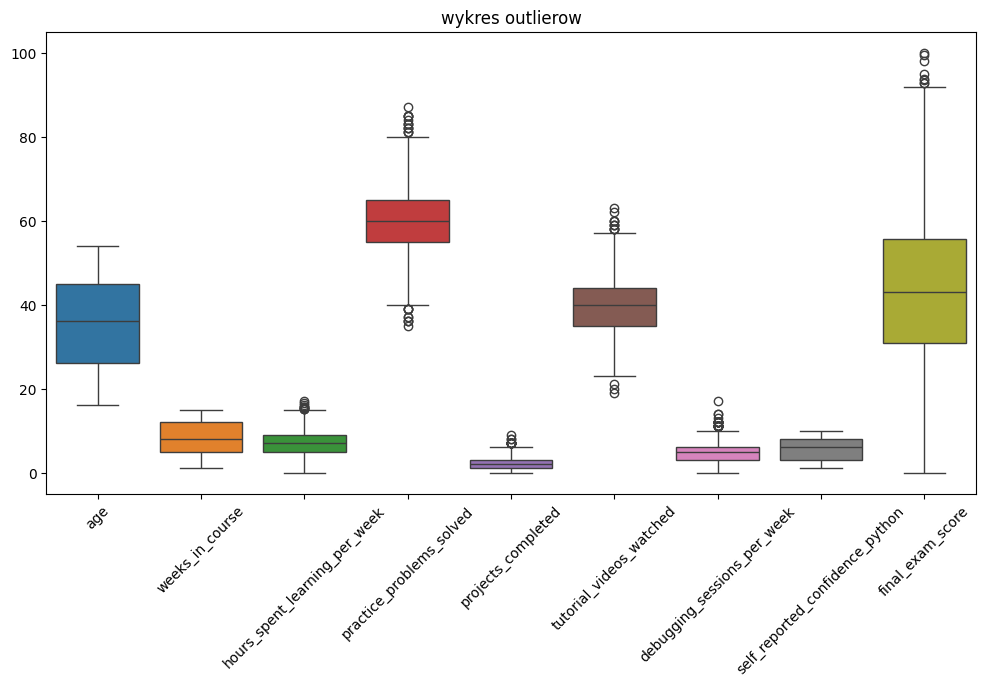

114 wierszy jest outlierami
     student_id  age    country prior_programming_experience  weeks_in_course  hours_spent_learning_per_week  practice_problems_solved  projects_completed  tutorial_videos_watched  uses_kaggle  participates_in_discussion_forums  debugging_sessions_per_week  self_reported_confidence_python  final_exam_score  passed_exam
43           44   43    Germany                 Intermediate                7                            3.5                        39                   3                       37            0                                  1                            3                                1              24.2            0
55           56   33        USA                no_experience               11                            1.8                        69                   8                       35            0                                  1                            8                                6              53.6            0
114      

In [8]:
#outliery
# wybieram kolumny numeryczne do sprawdzenia nie wliczając w to binarnych oraz id
numeryczne = df.select_dtypes(include=['number']).columns.tolist()
# wyrzucam binarne oraz id
kol_do_sprawdzenia = [c for c in numeryczne if c != 'student_id' and df[c].nunique() > 2]

print(f"analizowane kolumny: {kol_do_sprawdzenia}")

# rysuje wykres aby zobaczyć outliery
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[kol_do_sprawdzenia])
plt.xticks(rotation=45)
plt.title('wykres outlierow')
plt.show()

# IQR
Q1 = df[kol_do_sprawdzenia].quantile(0.25)
Q3 = df[kol_do_sprawdzenia].quantile(0.75)
IQR = Q3 - Q1

#znajduje outliery czyli wiersze mniejsze niż Q1-1.5*IQR lub większe niż Q3 1.5*IQR
outlier_condition = ((df[kol_do_sprawdzenia] < (Q1 - 1.5 * IQR)) | (df[kol_do_sprawdzenia] > (Q3 + 1.5 * IQR))).any(axis=1)
outlier_indices = df[outlier_condition].index

print(f"{len(outlier_indices)} wierszy jest outlierami")

# wiersze które usuwam
if len(outlier_indices) > 0:
    print(df.loc[outlier_indices].head(5).to_string())

#usunięcie
initial_rows = df.shape[0]
df = df[~outlier_condition].reset_index(drop=True)
print(f"było = {initial_rows} jest = {df.shape[0]}")

/tmp/ipython-input-2060561237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passed_exam', data=df, palette='viridis')


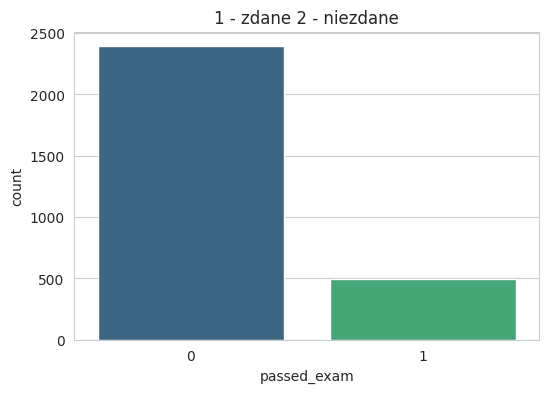

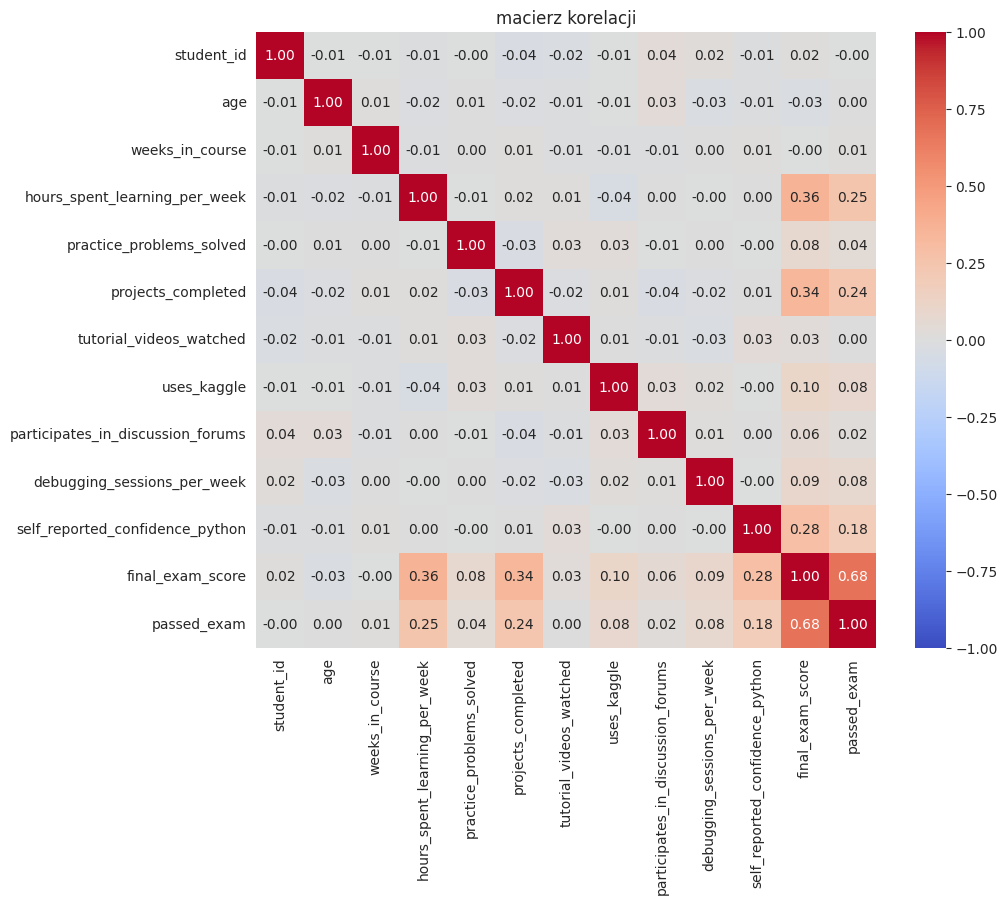

In [9]:
#EDA
#wykres ile osób zdało
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='passed_exam', data=df, palette='viridis')
plt.title('1 - zdane 2 - niezdane')
plt.show()
#macierz korelacji
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('macierz korelacji')
plt.show()

In [10]:
#przygotowanie danych
cols_to_drop = ['student_id', 'passed_exam', 'final_exam_score']
X = df.drop(columns=cols_to_drop)
y = df['passed_exam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
df.head()

,student_id,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,44,Nigeria,no_experience,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,36,UK,no_experience,3,3.5,62,1,47,1,0,3,7,24.8,0


In [11]:
#pipeline
bin_cols = ['uses_kaggle', 'participates_in_discussion_forums']
num_cols = [c for c in X.select_dtypes(include=['number']).columns if c not in bin_cols]
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('bin', 'passthrough', bin_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

In [12]:
#modele
models = {
    'Baseline (Dummy)': {
        'model': DummyClassifier(strategy='most_frequent'),
        'params': {}
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000,),
        'params': {'classifier__C': [0.01, 0.1, 1, 5, 10, 50]}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'classifier__max_depth': [3, 5, 10, 20, None],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [5, 10, 20, None],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    'k-NN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan']
        }
    },
    'Bernoulli NB': {
        'model': BernoulliNB(),
        'params': {
            'classifier__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
        }
    }
}

model: Baseline (Dummy)
najlepsze parametry: {}
model: Logistic Regression
najlepsze parametry: {'classifier__C': 50}
model: Decision Tree
najlepsze parametry: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_split': 10}
model: Random Forest
najlepsze parametry: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
model: k-NN
najlepsze parametry: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
model: Bernoulli NB
najlepsze parametry: {'classifier__alpha': 1.0}


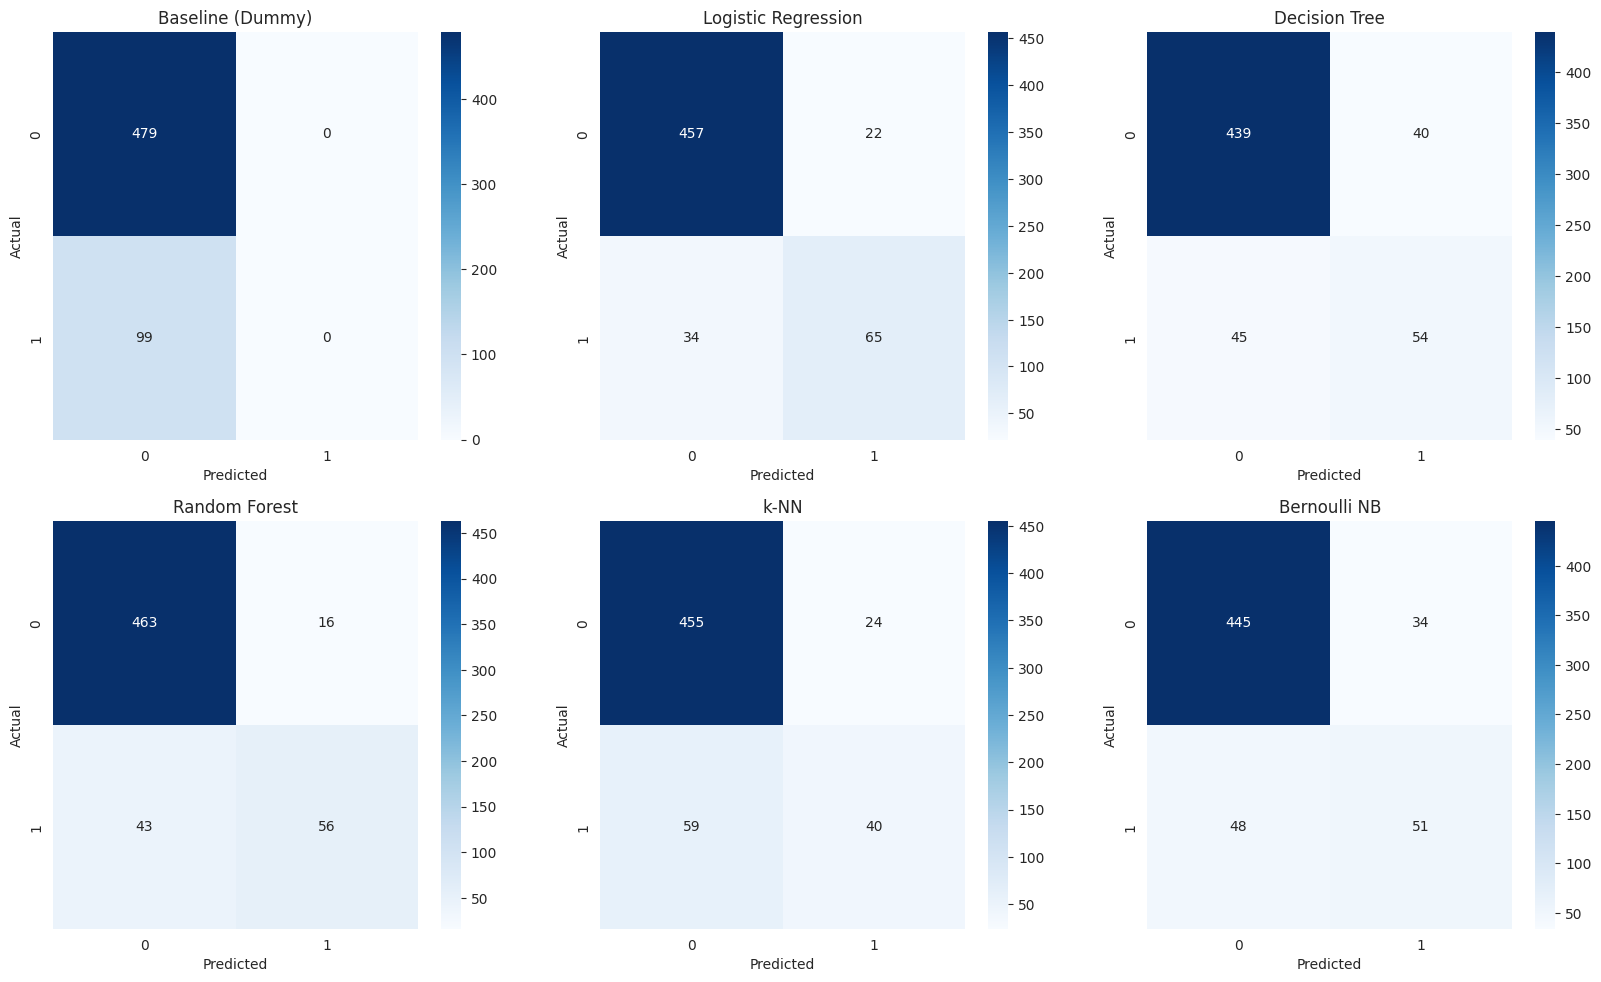

In [13]:
#trenowanie modeli
results = []
best_estimators = {}

n_models = len(models)
n_rows = (n_models + 1) // 3 + 1
plt.figure(figsize=(20, 6 * n_rows))
plot_idx = 1

for name, mp in models.items():
    print(f"model: {name}")

    # pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', mp['model'])])

    # gridSearch
    grid = GridSearchCV(clf, mp['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_estimators[name] = best_model

    print(f"najlepsze parametry: {grid.best_params_}")

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

    plt.subplot(n_rows, 3, plot_idx)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plot_idx += 1

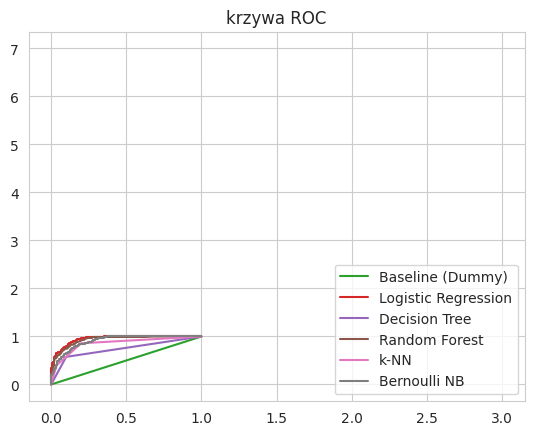

                 Model  Accuracy  F1-Score       AUC
0     Baseline (Dummy)  0.828720  0.000000  0.500000
1  Logistic Regression  0.906574  0.706522  0.950845
2        Decision Tree  0.844291  0.558824  0.737774
3        Random Forest  0.899654  0.637500  0.934670
4                 k-NN  0.866782  0.509554  0.853925
5         Bernoulli NB  0.875433  0.571429  0.906898


In [ ]:
#prezentacja wyników
plt.plot(n_rows, 5, plot_idx)
for name, model in best_estimators.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}')
plt.legend()
plt.title('krzywa ROC')
plt.show()

results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
print(results_df[['Model', 'Accuracy', 'F1-Score', 'AUC']])

/tmp/ipython-input-207706953.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gültigkeit', y='cecha', data=feat_df, palette='magma')


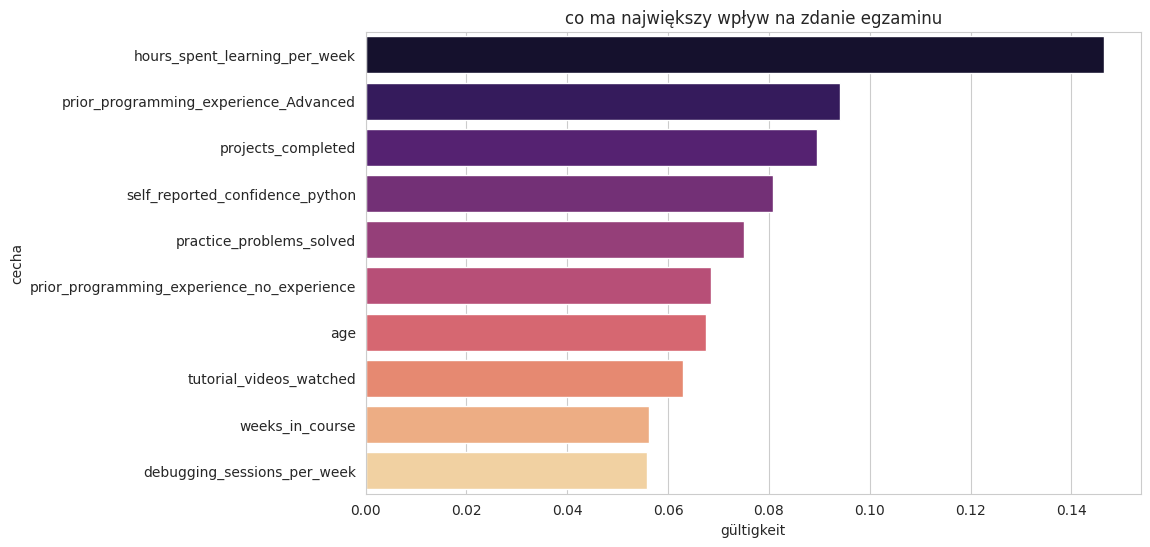

In [ ]:
#analiza ważności cech
rf_pipeline = best_estimators['Random Forest']
rf_model = rf_pipeline.named_steps['classifier']
preprocessor = rf_pipeline.named_steps['preprocessor']

cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = num_cols + bin_cols + list(cat_names)

feat_df = pd.DataFrame({'cecha': feature_names, 'gültigkeit': rf_model.feature_importances_})
feat_df = feat_df.sort_values(by='gültigkeit', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='gültigkeit', y='cecha', data=feat_df, palette='magma')
plt.title('co ma największy wpływ na zdanie egzaminu')
plt.show()

**Wnioski**

Po testach najlepszym modelem okazała się logistic regression.Jej kluczowe wartości takie jak AUC czy F1 są najlepsze w porównaniu do innych. Warto również zazanczyć że samo Accuracy większości modeli są na bardzo zbliżonym poziomie.

Model regresji uczy sie stabilnie i świetnie radzi sobie z zbiorem testowym, tym samym nie wykazując tendencji do żadnego overfittingu, co jest dosyć częstym problemem.